# Business Insight & Analysis
The product is growing, but the growth is not fully stable

Some weeks look healthy because many users keep coming back which is a good sign that the product is useful. But in other weeks, growth depends more on onboarding new users or bringing back users who had previously left and returned. This means growth is not consistent by loyal users, which makes it fragile.

The weekly quick ratio supports this. In some weeks, the product gains more users than it loses, but this does not happen every week. This tells us that churn still has a noticeable impact on growth

Drops in growth are mostly caused by users leaving, not by a lack of new users joining.
Therefore churn is the main problem, not acquisition

The priority should on keeping the users engaged, specially in the first few weeks.

Instead of spending more on acquiring new users, the business should improve onboarding so that the users see value faster, encourage repeat usage through reminders, content, or notifications, bring back recently churned users

# Growth Accounting Calculation & Visualization

In [1]:
import numpy as np 
import pandas as pd

In [2]:
df = pd.read_excel("Healthkart/Active_Users_Data.xlsx")
df.head()

,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10,...,w51,w52,w53,w54,w55,w56,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59
0,fd7c28f9fd8045f2,fd7c28f9fd8045f2,fd7c28f9fd8045f2,fd7c28f9fd8045f2,fd7c28f9fd8045f2,231d91be38352d7a,306243851b716bf6,149f7dd1efe25ebc,191a909000d7123d,191a909000d7123d,...,ffedb2a5b3b4838,ffedb2a5b3b4838,ffedb2a5b3b4838,fffe76c3a948cdfb,fffe76c3a948cdfb,fffe76c3a948cdfb,NaN,NaN,NaN,2.0
1,673000000000000,5ff4cd01b5eae601,1402081a023d5c18,45b649baf6882a4a,c92f828ffdd1c1c0,7c8de50e4a84f1ee,eff8ecf5cb54ffe7,b50740442eb78a75,e85d8cc04adae6cc,cf8dfdbbb526c506,...,bc1a7fed50193f41,bb1e4d0008cbabf,bb2e76bb3174a0be,bd0228ee50f09d79,bb4370c7306bb336,b81f04d72ef2e150,NaN,NaN,NaN,2.0
2,15600000000000000000000,7cd4b3218dbffa0b,99acf0df83dc2831,49740201a5f203eb,8cf94ff315895955,58453f722733b72e,7ec2e98a1613db6c,20e2a9da9c0146ee,fbeb97ecc066639,42aabbe8fa2b258a,...,a7292f3d0d80985b,a5d5d8560d64b95a,a7914920e3ef2b55,a95f016d03945e5c,a6e99e4acd1701d6,a3c2066710a6d65,NaN,NaN,NaN,2.0
3,10156b703e26c334,25167a08527132ac,4820782b3cb8f570,ae16cc7b72fcee52,ecaa9c1913ef2f65,e02ecf94fd8ee5c8,1aba368c76311ef3,49b64be1edab128c,6dff050c07b69b4e,b6be357ac8671a1f,...,9eef01de4af7d619,9d6d4be4eab27e4b,a01148c9b12f3c15,a29b81926b57d967,9f5835c16ef759bb,9af6497cd753b9b9,NaN,NaN,NaN,2.0
4,103f96126c333035,7fbf03c17ea12589,d8aaa5b13424da35,bd26c51dd185a3cb,6028ea4b2b053007,b5c3d0e920ed6175,fa45dfe1357d3db9,b9928cbdfb35c1,d6a7f937733dea7,b7a452cfbee2d008,...,d7f6ec45f8815d98,d6ec98374c4a453,d7415d7979ce86d9,d84e5dc003ef9155,d851694a086bfc17,d63515fbe6484033,NaN,NaN,NaN,2.0


In [3]:
#removes the columns what dosent start with "w" (baically filtering out the useless data)
week_cols = [col for col in df.columns if col.startswith("w")]
df = df[week_cols]

In [4]:
#converting df into melted form
melted_df = df.melt(
    value_vars = week_cols,
    var_name = "week",
    value_name = "user_id"
)

In [5]:
#dropping NAN values -> because NAN value means user was incative that week, but growth accounting works on active user events
melted_df = melted_df.dropna()

In [6]:
# slicing "w" from week column to get only numeric value and then converting it to int value(because it will be used in growth accounting (curr_week = prev_week + 1))

melted_df["week"] = melted_df["week"].str[1:].astype(int)

In [7]:
melted_df

,week,user_id
0,1,fd7c28f9fd8045f2
1,1,673000000000000
2,1,15600000000000000000000
3,1,10156b703e26c334
4,1,103f96126c333035
...,...,...
224461,56,09579ca50f8ccf1e
224462,56,08327e11594463ee
224463,56,06d923eca95ca29a
224464,56,06136366972b19ac


In [8]:
#computing in which week each user appeard first
first_week = (melted_df.groupby("user_id")["week"].min().reset_index().rename(columns={"week": "first_week_of_each_user"}))

melted_df = melted_df.merge(first_week, on="user_id", how="left")

In [9]:
melted_df

,week,user_id,first_week_of_each_user
0,1,fd7c28f9fd8045f2,1
1,1,673000000000000,1
2,1,15600000000000000000000,1
3,1,10156b703e26c334,1
4,1,103f96126c333035,1
...,...,...,...
172376,56,09579ca50f8ccf1e,55
172377,56,08327e11594463ee,55
172378,56,06d923eca95ca29a,55
172379,56,06136366972b19ac,41


In [10]:
weeks = sorted(melted_df["week"].unique())

#rows where week = current week it takes the user_id and convert it into a set and store it in a dictionary
weekly_users = {
    week: set(melted_df[melted_df["week"] == week]["user_id"])
    for week in weeks
}

In [11]:
results = []

for i in range(1, len(weeks)):  #week1 has no previous week, therefore comparison starts from week2
    curr_week = weeks[i]
    prev_week = weeks[i - 1]

    U_t = weekly_users[curr_week]
    U_t_1 = weekly_users[prev_week]

    retained = U_t & U_t_1 #gives intersection for previous and this week 
    churned = U_t_1 - U_t  #users active last week but not this week

    new_users = set(        
        melted_df[
            (melted_df["week"] == curr_week) &
            (melted_df["first_week_of_each_user"] == curr_week)]["user_id"])   # gives uses that are active this week and users which have this as their first week

    resurrected = U_t - retained - new_users

    results.append({"week": curr_week, "new": len(new_users), "retained": len(retained), "resurrected": len(resurrected), "churned": len(churned),"wau": len(U_t)})

In [12]:
growth_df = pd.DataFrame(results)
growth_df.head()

,week,new,retained,resurrected,churned,wau
0,2,723,931,0,828,1654
1,3,645,1000,87,654,1732
2,4,722,1169,225,563,2116
3,5,674,1394,125,722,2193
4,6,489,1479,187,714,2155


In [13]:
#calculating quick ratio
growth_df["quick_ratio"] = ((growth_df["new"] + growth_df["resurrected"]) / growth_df["churned"].replace(0, np.nan))

In [15]:
#checking if our logic is correct or not
growth_df["check"] = (
    growth_df["new"] +
    growth_df["retained"] +
    growth_df["resurrected"]
)

assert all(growth_df["check"] == growth_df["wau"])

In [16]:
import matplotlib.pyplot as plt

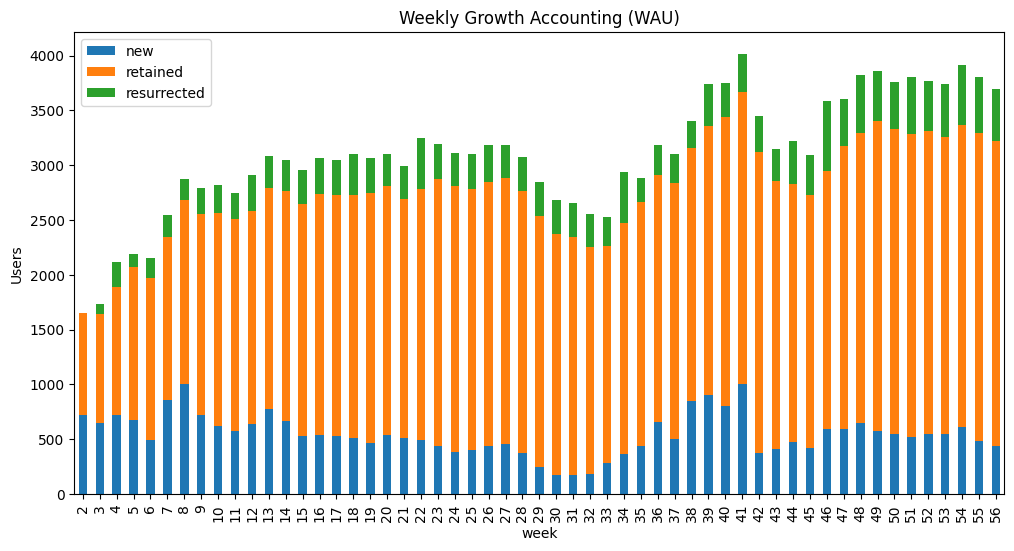

In [20]:
growth_df.set_index("week")[["new", "retained", "resurrected"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    title="Weekly Growth Accounting (WAU)"
)

plt.ylabel("Users")
plt.show()

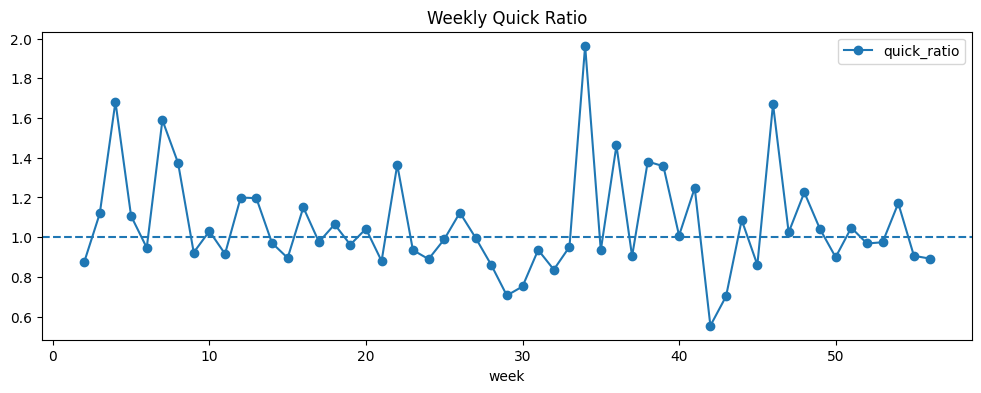

In [21]:
growth_df.plot(
    x="week",
    y="quick_ratio",
    kind="line",
    marker="o",
    figsize=(12,4),
    title="Weekly Quick Ratio"
)

plt.axhline(1, linestyle="--")
plt.show()